# DINOv2-Small U1 self-training on Cityscapes + ACDC pseudo-labels

This notebook fine-tunes a `DINOv2-Small` student on labeled `Cityscapes` plus confidence-filtered pseudo-labels generated for `ACDC train`.
The student is initialized from the best source-only `DINOv2 E3` checkpoint.


In [1]:
!pip install -q albumentations torchmetrics pytorch-lightning clearml python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 95.0 MB/s eta 0:00:00


In [2]:
import os
import math
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import albumentations as A
from albumentations.pytorch import ToTensorV2

import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback, TQDMProgressBar
from torchmetrics import JaccardIndex

from clearml import Task
from google.colab import drive, userdata


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
CONFIG = {
    "project_name": "Segmentation_Urban_Scene_CourseWork",
    "task_name": "DinoV2_Small_U1_Cityscapes_ACDC_PseudoLabelSelfTraining",
    "cityscapes_dir": "/content/data/cityscapes",
    "cityscapes_zips": [
        "leftImg8bit_trainvaltest.zip",
        "gtFine_trainvaltest.zip",
    ],
    "drive_root": "/content/drive/MyDrive",
    "init_weights_rel_path": "weights/dinov2-small-E3-cityscapes-epoch=44-val_miou=0.6406.ckpt",
    "pseudo_labels_rel_path": "pseudo_labels/acdc/dinov2_e3_u1_round1",
    "acdc_zips": [
        "rgb_anon_trainvaltest.zip",
    ],
    "acdc_data_dir": "/content/data/acdc",
    "weights_export_rel_dir": "weights",
    "model_name": "dinov2_vits14",
    "classes": 19,
    "batch_size": 16,
    "lr": 5e-5,
    "weight_decay": 0.05,
    "epochs": 20,
    "image_size": (518, 1022),
    "freeze_backbone": False,
    "num_workers": 4,
    "source_loss_weight": 1.0,
    "target_loss_weight": 0.7,
    "target_repeat_factor": None,
    "pseudo_confidence_threshold": 0.90,
    "check_val_every_n_epoch": 1,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

torch.set_float32_matmul_precision("medium")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

os.environ["CLEARML_API_ACCESS_KEY"] = userdata.get("CLEARML_API_ACCESS_KEY")
os.environ["CLEARML_API_SECRET_KEY"] = userdata.get("CLEARML_API_SECRET_KEY")

task = Task.init(
    project_name=CONFIG["project_name"],
    task_name=CONFIG["task_name"],
    output_uri=False,
)
task.connect(CONFIG)


ClearML Task: created new task id=87a2e1301776497db6491052434eb8e4


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-03-29 13:01:41,145 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/588d5d925230490b9f98b1007b4c7fa0/experiments/87a2e1301776497db6491052434eb8e4/output/log


{'project_name': 'Segmentation_Urban_Scene_CourseWork',
 'task_name': 'DinoV2_Small_U1_Cityscapes_ACDC_PseudoLabelSelfTraining',
 'cityscapes_dir': '/content/data/cityscapes',
 'cityscapes_zips': ['leftImg8bit_trainvaltest.zip',
  'gtFine_trainvaltest.zip'],
 'drive_root': '/content/drive/MyDrive',
 'init_weights_rel_path': 'weights/dinov2-small-E3-cityscapes-epoch=44-val_miou=0.6406.ckpt',
 'pseudo_labels_rel_path': 'pseudo_labels/acdc/dinov2_e3_u1_round1',
 'acdc_zips': ['rgb_anon_trainvaltest.zip'],
 'acdc_data_dir': '/content/data/acdc',
 'weights_export_rel_dir': 'weights',
 'model_name': 'dinov2_vits14',
 'classes': 19,
 'batch_size': 16,
 'lr': 5e-05,
 'weight_decay': 0.05,
 'epochs': 20,
 'image_size': (518, 1022),
 'freeze_backbone': False,
 'num_workers': 4,
 'source_loss_weight': 1.0,
 'target_loss_weight': 0.7,
 'target_repeat_factor': None,
 'pseudo_confidence_threshold': 0.9,
 'check_val_every_n_epoch': 1,
 'early_stopping_patience': 4,
 'early_stopping_min_delta': 0.001,

In [5]:
Path(CONFIG["cityscapes_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["acdc_data_dir"]).mkdir(parents=True, exist_ok=True)

for zip_name in CONFIG["cityscapes_zips"]:
    zip_path = Path(CONFIG["drive_root"]) / zip_name
    if not zip_path.exists():
        raise FileNotFoundError(f"Cityscapes zip not found: {zip_path}")

    print(f"Unpacking {zip_path} -> {CONFIG['cityscapes_dir']}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(CONFIG["cityscapes_dir"])

for zip_name in CONFIG["acdc_zips"]:
    zip_path = Path(CONFIG["drive_root"]) / zip_name
    if not zip_path.exists():
        raise FileNotFoundError(f"ACDC zip not found: {zip_path}")

    print(f"Unpacking {zip_path} -> {CONFIG['acdc_data_dir']}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(CONFIG["acdc_data_dir"])

cityscapes_left = Path(CONFIG["cityscapes_dir"]) / "leftImg8bit" / "train"
cityscapes_gt = Path(CONFIG["cityscapes_dir"]) / "gtFine" / "train"
if not cityscapes_left.exists() or not cityscapes_gt.exists():
    raise FileNotFoundError(
        f"Cityscapes train folders not found after extraction: {cityscapes_left} | {cityscapes_gt}"
    )

init_weights_path = Path(CONFIG["drive_root"]) / CONFIG["init_weights_rel_path"]
if not init_weights_path.exists():
    raise FileNotFoundError(f"Init checkpoint not found: {init_weights_path}")

pseudo_labels_root = Path(CONFIG["drive_root"]) / CONFIG["pseudo_labels_rel_path"]
if not pseudo_labels_root.exists():
    raise FileNotFoundError(f"Pseudo-label root not found: {pseudo_labels_root}")

export_weights_dir = Path(CONFIG["drive_root"]) / CONFIG["weights_export_rel_dir"]
export_weights_dir.mkdir(parents=True, exist_ok=True)

print(f"Cityscapes dir: {CONFIG['cityscapes_dir']}")
print(f"Init checkpoint: {init_weights_path}")
print(f"Pseudo-label root: {pseudo_labels_root}")


Unpacking /content/drive/MyDrive/leftImg8bit_trainvaltest.zip -> /content/data/cityscapes
Unpacking /content/drive/MyDrive/gtFine_trainvaltest.zip -> /content/data/cityscapes
Unpacking /content/drive/MyDrive/rgb_anon_trainvaltest.zip -> /content/data/acdc
Cityscapes dir: /content/data/cityscapes
Init checkpoint: /content/drive/MyDrive/weights/dinov2-small-E3-cityscapes-epoch=44-val_miou=0.6406.ckpt
Pseudo-label root: /content/drive/MyDrive/pseudo_labels/acdc/dinov2_e3_u1_round1


In [6]:
class CityscapesDataset(Dataset):
    def __init__(self, root_dir, split="train", augmentation=None, is_target=False):
        self.root_dir = root_dir
        self.images_dir = os.path.join(root_dir, "leftImg8bit", split)
        self.masks_dir = os.path.join(root_dir, "gtFine", split)
        self.augmentation = augmentation
        self.is_target = is_target
        self.ids = []

        for city in os.listdir(self.images_dir):
            img_dir = os.path.join(self.images_dir, city)
            mask_dir = os.path.join(self.masks_dir, city)
            for file_name in os.listdir(img_dir):
                if file_name.endswith("_leftImg8bit.png"):
                    self.ids.append(
                        {
                            "image": os.path.join(img_dir, file_name),
                            "mask": os.path.join(
                                mask_dir,
                                file_name.replace("_leftImg8bit.png", "_gtFine_labelIds.png"),
                            ),
                        }
                    )

        self.mapping = {
            7: 0, 8: 1, 11: 2, 12: 3, 13: 4, 17: 5, 19: 6, 20: 7, 21: 8, 22: 9,
            23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 31: 16, 32: 17, 33: 18,
        }

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample = self.ids[idx]
        image = cv2.imread(sample["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample["mask"], 0)

        mask_mapped = np.ones_like(mask) * 255
        for raw_id, train_id in self.mapping.items():
            mask_mapped[mask == raw_id] = train_id
        mask = mask_mapped

        if self.augmentation is not None:
            transformed = self.augmentation(image=image, mask=mask)
            image, mask = transformed["image"], transformed["mask"]

        return {
            "image": image,
            "mask": mask.long(),
            "is_target": torch.tensor(0.0, dtype=torch.float32),
        }


class ACDCPseudoLabelDataset(Dataset):
    def __init__(self, acdc_root, pseudo_root, split="train", conditions=None, augmentation=None):
        self.acdc_root = Path(acdc_root)
        self.pseudo_root = Path(pseudo_root)
        self.split = split
        self.conditions = conditions or ["fog", "night", "rain", "snow"]
        self.augmentation = augmentation
        self.items = []

        for condition in self.conditions:
            rgb_root = self.acdc_root / "rgb_anon" / condition / split
            pseudo_condition_root = self.pseudo_root / condition / split
            if not rgb_root.exists() or not pseudo_condition_root.exists():
                continue

            for image_path in sorted(rgb_root.rglob("*_rgb_anon.png")):
                rel = image_path.relative_to(rgb_root)
                mask_name = image_path.name.replace("_rgb_anon.png", "_gt_labelTrainIds.png")
                pseudo_path = pseudo_condition_root / rel.parent / mask_name
                if pseudo_path.exists():
                    self.items.append(
                        {
                            "image": str(image_path),
                            "mask": str(pseudo_path),
                            "condition": condition,
                            "stem": image_path.stem,
                        }
                    )

        if len(self.items) == 0:
            raise RuntimeError("No ACDC pseudo-labeled pairs found.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        sample = self.items[idx]
        image = cv2.imread(sample["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample["mask"], 0)

        if image.shape[:2] != mask.shape[:2]:
            image = cv2.resize(image, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_LINEAR)

        if self.augmentation is not None:
            transformed = self.augmentation(image=image, mask=mask)
            image, mask = transformed["image"], transformed["mask"]

        return {
            "image": image,
            "mask": mask.long(),
            "is_target": torch.tensor(1.0, dtype=torch.float32),
        }


class MixedUDATrainDataset(Dataset):
    def __init__(self, source_dataset, target_dataset, target_repeat_factor=1):
        self.source_dataset = source_dataset
        self.target_dataset = target_dataset
        self.target_repeat_factor = max(1, int(target_repeat_factor))
        self.source_len = len(source_dataset)
        self.target_len = len(target_dataset) * self.target_repeat_factor

    def __len__(self):
        return self.source_len + self.target_len

    def __getitem__(self, idx):
        if idx < self.source_len:
            return self.source_dataset[idx]
        target_idx = (idx - self.source_len) % len(self.target_dataset)
        return self.target_dataset[target_idx]


class RoadDataModule(pl.LightningDataModule):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.actual_target_repeat_factor = 1

    def setup(self, stage=None):
        self.source_train_transform = A.Compose([
            A.Resize(height=self.config["image_size"][0], width=self.config["image_size"][1]),
            A.HorizontalFlip(p=0.5),
            A.OneOf([
                A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
                A.RandomGamma(gamma_limit=(70, 120), p=1.0),
                A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
                A.RandomShadow(p=1.0),
            ], p=0.75),
            A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.08, p=0.4),
            A.OneOf([
                A.RandomFog(p=1.0),
                A.RandomRain(blur_value=3, brightness_coefficient=0.9, p=1.0),
                A.RandomSnow(p=1.0),
            ], p=0.35),
            A.OneOf([
                A.GaussNoise(p=1.0),
                A.GaussianBlur(blur_limit=(3, 7), p=1.0),
                A.MotionBlur(blur_limit=5, p=1.0),
            ], p=0.25),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])

        self.target_train_transform = A.Compose([
            A.Resize(height=self.config["image_size"][0], width=self.config["image_size"][1]),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
            A.GaussianBlur(blur_limit=(3, 5), p=0.1),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])

        self.valid_transform = A.Compose([
            A.Resize(height=self.config["image_size"][0], width=self.config["image_size"][1]),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])

        self.source_train_ds = CityscapesDataset(
            self.config["cityscapes_dir"],
            split="train",
            augmentation=self.source_train_transform,
        )
        self.target_train_ds = ACDCPseudoLabelDataset(
            self.config["acdc_data_dir"],
            pseudo_labels_root,
            split="train",
            conditions=["fog", "night", "rain", "snow"],
            augmentation=self.target_train_transform,
        )

        if self.config["target_repeat_factor"] is None:
            self.actual_target_repeat_factor = max(
                1,
                int(round(len(self.source_train_ds) / max(len(self.target_train_ds), 1))),
            )
        else:
            self.actual_target_repeat_factor = max(1, int(self.config["target_repeat_factor"]))

        self.train_ds = MixedUDATrainDataset(
            self.source_train_ds,
            self.target_train_ds,
            target_repeat_factor=self.actual_target_repeat_factor,
        )
        self.val_ds = CityscapesDataset(
            self.config["cityscapes_dir"],
            split="val",
            augmentation=self.valid_transform,
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.config["batch_size"],
            shuffle=True,
            num_workers=self.config["num_workers"],
            pin_memory=True,
            persistent_workers=self.config["num_workers"] > 0,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.config["batch_size"],
            shuffle=False,
            num_workers=self.config["num_workers"],
            pin_memory=True,
            persistent_workers=self.config["num_workers"] > 0,
        )


In [7]:
class LinearSegmentationHead(nn.Module):
    def __init__(self, embed_dim=384, num_classes=19, patch_size=14):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.linear = nn.Conv2d(embed_dim, num_classes, kernel_size=1)

    def forward(self, x, h, w):
        batch_size, n_tokens, channels = x.shape
        patch_h = h // self.patch_size
        patch_w = w // self.patch_size
        x = x.reshape(batch_size, patch_h, patch_w, channels).permute(0, 3, 1, 2)
        x = self.linear(x)
        x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return x


class ClearMLMetricsCallback(Callback):
    def __init__(self, task):
        super().__init__()
        self._logger = task.get_logger()

    def _log_metrics(self, trainer, stage):
        for name, value in trainer.callback_metrics.items():
            if isinstance(value, torch.Tensor):
                value = value.detach().cpu().item()
            if isinstance(value, (int, float)) and math.isfinite(value):
                self._logger.report_scalar(stage, name, value, iteration=trainer.current_epoch)

    def on_train_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "train")

    def on_validation_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "val")


class RoadModel(pl.LightningModule):
    def __init__(
        self,
        model_name="dinov2_vits14",
        num_classes=19,
        lr=5e-5,
        weight_decay=0.05,
        epochs=20,
        freeze_backbone=False,
        source_loss_weight=1.0,
        target_loss_weight=0.7,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.backbone = torch.hub.load("facebookresearch/dinov2", model_name)
        self.embed_dim = 384
        self.patch_size = 14

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.segmentation_head = LinearSegmentationHead(
            embed_dim=self.embed_dim,
            num_classes=num_classes,
            patch_size=self.patch_size,
        )

        self.criterion = nn.CrossEntropyLoss(ignore_index=255, reduction="none")
        self.train_miou = JaccardIndex(task="multiclass", num_classes=num_classes, ignore_index=255)
        self.val_miou = JaccardIndex(task="multiclass", num_classes=num_classes, ignore_index=255)

    def forward(self, x):
        _, _, h, w = x.shape
        features = self.backbone.forward_features(x)
        patch_features = features["x_norm_patchtokens"]
        logits = self.segmentation_head(patch_features, h, w)
        return logits

    def _mean_valid_loss(self, logits, masks):
        loss_map = self.criterion(logits, masks)
        valid = (masks != 255).float()
        denom = valid.sum(dim=(1, 2)).clamp_min(1.0)
        per_sample = (loss_map * valid).sum(dim=(1, 2)) / denom
        return per_sample, valid

    def training_step(self, batch, batch_idx):
        images = batch["image"]
        masks = batch["mask"]
        is_target = batch["is_target"].to(self.device)

        logits = self(images)
        per_sample_loss, valid = self._mean_valid_loss(logits, masks)

        sample_weights = torch.where(
            is_target > 0.5,
            torch.full_like(is_target, self.hparams.target_loss_weight),
            torch.full_like(is_target, self.hparams.source_loss_weight),
        )
        loss = (per_sample_loss * sample_weights).sum() / sample_weights.sum().clamp_min(1e-6)

        preds = torch.argmax(logits, dim=1)
        self.train_miou(preds, masks)

        source_mask = is_target < 0.5
        target_mask = is_target > 0.5
        source_loss = per_sample_loss[source_mask].mean() if source_mask.any() else torch.tensor(0.0, device=self.device)
        target_loss = per_sample_loss[target_mask].mean() if target_mask.any() else torch.tensor(0.0, device=self.device)
        target_keep_ratio = valid[target_mask].mean() if target_mask.any() else torch.tensor(0.0, device=self.device)

        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log("train_source_loss", source_loss, on_step=False, on_epoch=True, logger=True)
        self.log("train_target_loss", target_loss, on_step=False, on_epoch=True, logger=True)
        self.log("train_target_keep_ratio", target_keep_ratio, on_step=False, on_epoch=True, logger=True)
        self.log("train_miou", self.train_miou, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        return loss

    def validation_step(self, batch, batch_idx):
        images = batch["image"]
        masks = batch["mask"]
        logits = self(images)
        per_sample_loss, _ = self._mean_valid_loss(logits, masks)
        loss = per_sample_loss.mean()

        preds = torch.argmax(logits, dim=1)
        self.val_miou(preds, masks)

        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_miou", self.val_miou, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        if self.hparams.freeze_backbone:
            params = self.segmentation_head.parameters()
        else:
            params = [
                {"params": self.segmentation_head.parameters(), "lr": self.hparams.lr},
                {"params": self.backbone.parameters(), "lr": self.hparams.lr * 0.1},
            ]

        optimizer = torch.optim.AdamW(
            params,
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
            betas=(0.9, 0.999),
            eps=1e-8,
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.hparams.epochs,
            eta_min=1e-6,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
            },
        }


def load_lightning_weights_into_model(model, ckpt_path, device):
    checkpoint = torch.load(ckpt_path, map_location=device)
    state_dict = checkpoint.get("state_dict", checkpoint)

    filtered_state = {}
    for key, value in state_dict.items():
        if key.startswith("backbone.") or key.startswith("segmentation_head."):
            filtered_state[key] = value

    missing, unexpected = model.load_state_dict(filtered_state, strict=False)
    print(f"Loaded init checkpoint from: {ckpt_path}")
    print(f"Missing keys: {len(missing)}")
    print(f"Unexpected keys: {len(unexpected)}")


In [8]:
dm = RoadDataModule(CONFIG)
dm.setup()

print(f"Cityscapes train samples: {len(dm.source_train_ds)}")
print(f"ACDC pseudo-labeled train samples: {len(dm.target_train_ds)}")
print(f"Target repeat factor: {dm.actual_target_repeat_factor}")
print(f"Mixed train samples: {len(dm.train_ds)}")

model = RoadModel(
    model_name=CONFIG["model_name"],
    num_classes=CONFIG["classes"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    epochs=CONFIG["epochs"],
    freeze_backbone=CONFIG["freeze_backbone"],
    source_loss_weight=CONFIG["source_loss_weight"],
    target_loss_weight=CONFIG["target_loss_weight"],
)
load_lightning_weights_into_model(model, str(init_weights_path), CONFIG["device"])

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_miou",
    dirpath="./checkpoints",
    filename="dinov2-small-U1-cityscapes-acdc-{epoch:02d}-{val_miou:.4f}",
    save_top_k=1,
    mode="max",
)

early_stopping = pl.callbacks.EarlyStopping(
    monitor="val_miou",
    patience=CONFIG["early_stopping_patience"],
    min_delta=CONFIG["early_stopping_min_delta"],
    mode="max",
)

trainer = pl.Trainer(
    max_epochs=CONFIG["epochs"],
    accelerator="gpu",
    devices=1,
    logger=True,
    callbacks=[
        checkpoint_callback,
        early_stopping,
        TQDMProgressBar(refresh_rate=20),
        ClearMLMetricsCallback(task),
    ],
    precision="16-mixed",
    accumulate_grad_batches=4,
    check_val_every_n_epoch=CONFIG["check_val_every_n_epoch"],
)

trainer.fit(model, datamodule=dm)


Cityscapes train samples: 2975
ACDC pseudo-labeled train samples: 1600
Target repeat factor: 2
Mixed train samples: 6175
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning:

xFormers is not available (SwiGLU)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning:

xFormers is not available (Attention)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning:

xFormers is not available (Block)



Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 208MB/s]


2026-03-29 13:22:44,709 - clearml.model - INFO - Selected model id: 096af8490ce44af1b6986ef1b35ef075
2026-03-29 13:23:21,191 - clearml.model - INFO - Selected model id: 3607601e277f48e0a32bd60c92c4c58d


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


2026-03-29 13:57:17,533 - clearml.model - WARNING - Connecting multiple input models with the same name: `dinov2_vits14_pretrain`. This might result in the wrong model being used when executing remotely
Copied best checkpoint to: /content/drive/MyDrive/weights/dinov2-small-U1-cityscapes-acdc-epoch=05-val_miou=0.7110.ckpt


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.1634339541196823     │
│         val_miou          │    0.7109695672988892     │
└───────────────────────────┴───────────────────────────┘

,Metric,Value
0,Loss,0.1634
1,mIoU,0.7110
2,Percent,71.10%


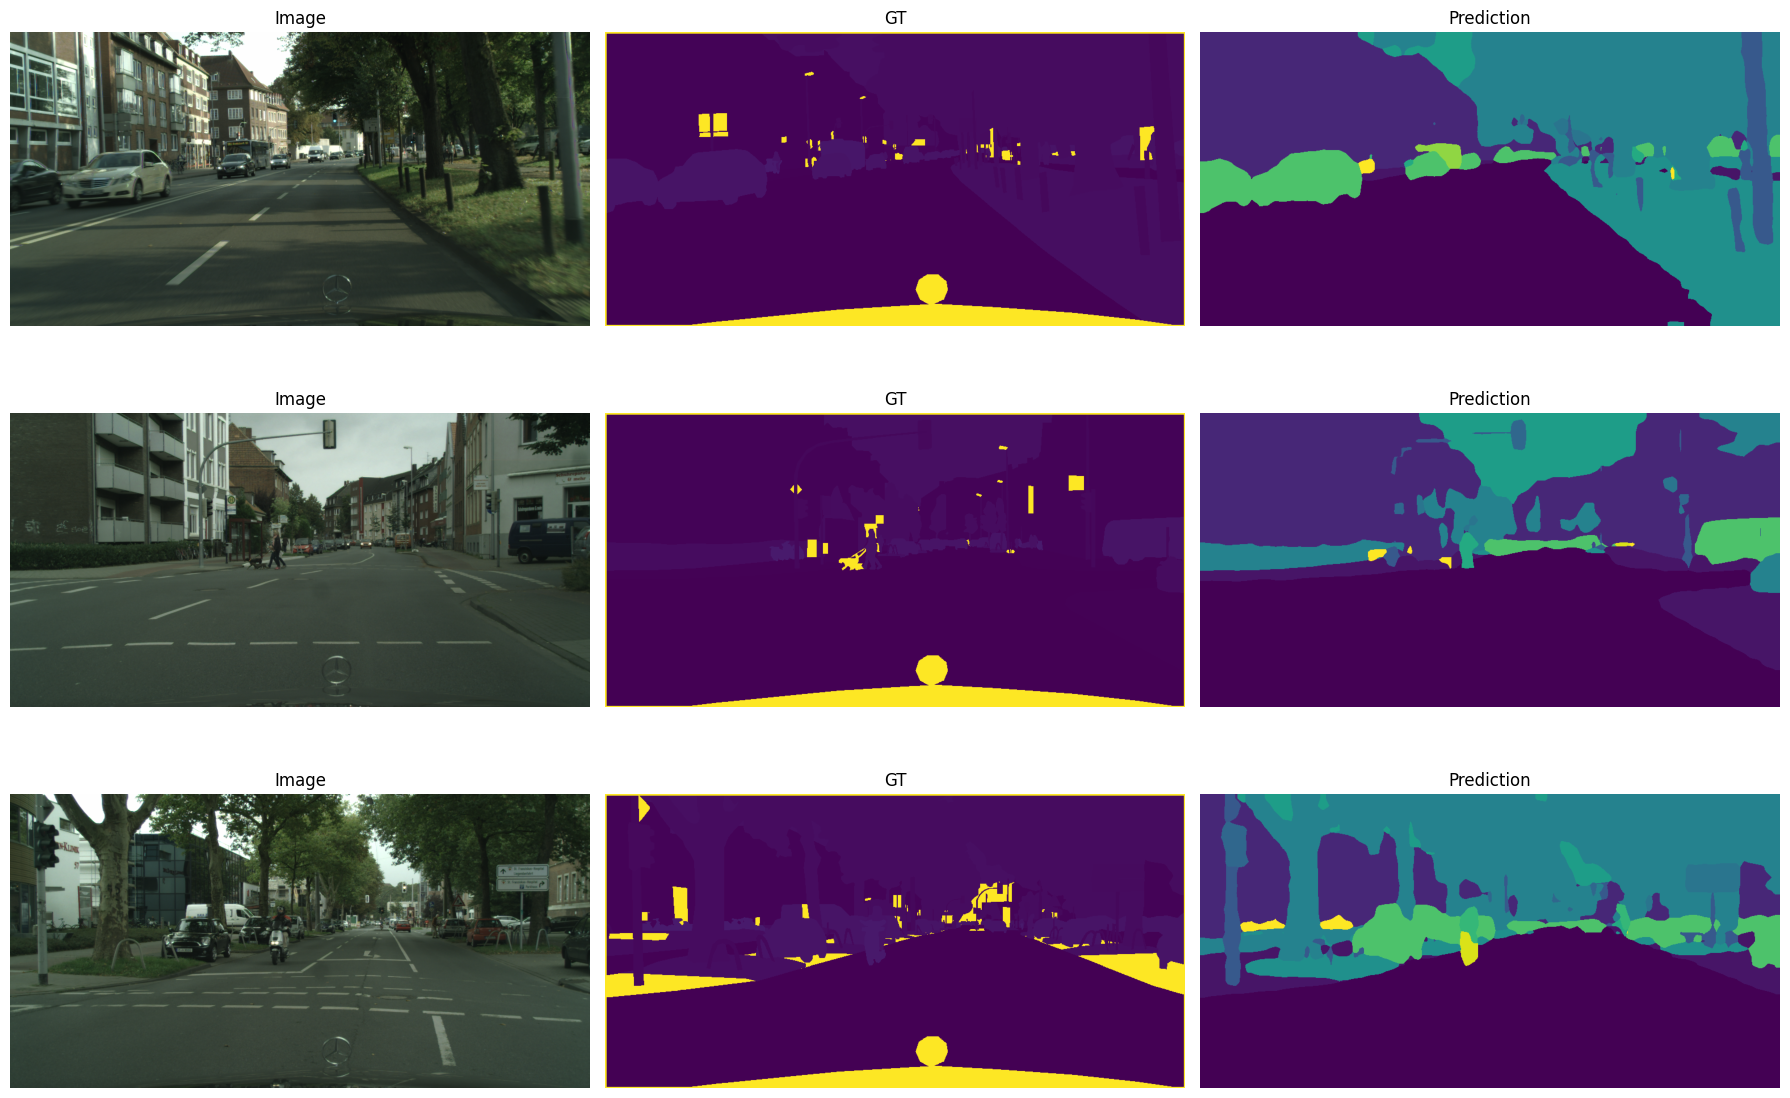

In [9]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = RoadModel.load_from_checkpoint(best_model_path)
best_model.to(CONFIG["device"])
best_model.eval()

export_path = export_weights_dir / Path(best_model_path).name
shutil.copy2(best_model_path, export_path)
print(f"Copied best checkpoint to: {export_path}")

val_results = trainer.validate(best_model, datamodule=dm)[0]

metrics_data = {
    "Metric": ["Loss", "mIoU", "Percent"],
    "Value": [
        f"{val_results['val_loss']:.4f}",
        f"{val_results['val_miou']:.4f}",
        f"{val_results['val_miou'] * 100:.2f}%",
    ],
}
display(pd.DataFrame(metrics_data))


def visualize_predictions(model, datamodule, num_samples=3):
    model.to(CONFIG["device"])
    model.eval()

    val_loader = datamodule.val_dataloader()
    batch = next(iter(val_loader))
    images = batch["image"].to(CONFIG["device"])
    masks = batch["mask"].cpu()

    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu()

    images = images.cpu()
    plt.figure(figsize=(18, num_samples * 4))

    for idx in range(min(num_samples, len(images))):
        img = images[idx].permute(1, 2, 0).numpy()
        mean = np.array(IMAGENET_MEAN)
        std = np.array(IMAGENET_STD)
        img = np.clip(std * img + mean, 0, 1)

        plt.subplot(num_samples, 3, idx * 3 + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, idx * 3 + 2)
        plt.imshow(masks[idx])
        plt.title("GT")
        plt.axis("off")

        plt.subplot(num_samples, 3, idx * 3 + 3)
        plt.imshow(preds[idx])
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(best_model, dm)


In [10]:
current_task = Task.get_task(task_id=task.id)
current_task.update_output_model(
    model_path=best_model_path,
    model_name=Path(best_model_path).name,
    iteration=trainer.current_epoch,
)

task.close()


█████████████████████████████ 100% | 252.71/252.71 MB [00:23<00:00, 10.96MB/s]: 
